# Group project 2
# Submitted by: Rishi Ram, Vikas Gautam
# Date: 6/1/2025


In [2]:
!pip install kaggle

In [3]:
!pip install opendatasets
!pip install pandas

In [4]:
import opendatasets as od
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.decomposition import PCA
import numpy as np
import seaborn as sns
from mlxtend.preprocessing import standardize
from mlxtend.feature_extraction import LinearDiscriminantAnalysis as lda2

In [5]:
#od.download("https://www.kaggle.com/datasets/rashmi08singh/tesla-stock-market-dataset")

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os
print(os.listdir('/content/drive/My Drive/WQU/GRp7797/proj2'))

['Stars.csv', 'GRp proj2_M5.docx', 'Grp 7797_proj2_M5.ipynb']


In [9]:
#import zipfile
#import os

#with zipfile.ZipFile("./archive.zip", 'r') as zip_ref:
#    zip_ref.extractall("stars")

In [10]:
dataset=pd.read_csv("/content/drive/My Drive/WQU/GRp7797/proj2/Stars.csv")
dataset.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0


In [11]:
dataset.shape

(240, 7)

In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
 6   Type            240 non-null    int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 13.2+ KB


In [13]:
dataset.describe()

,Temperature,L,R,A_M,Type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


In [14]:
data1=dataset.copy()
# Convert 'Color' and 'Spectral Class' columns to categorical
data1['Color'] = data1['Color'].astype('category')
data1['Spectral_Class'] = data1['Spectral_Class'].astype('category')
data1['Type'] = data1['Type'].astype('category')

plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

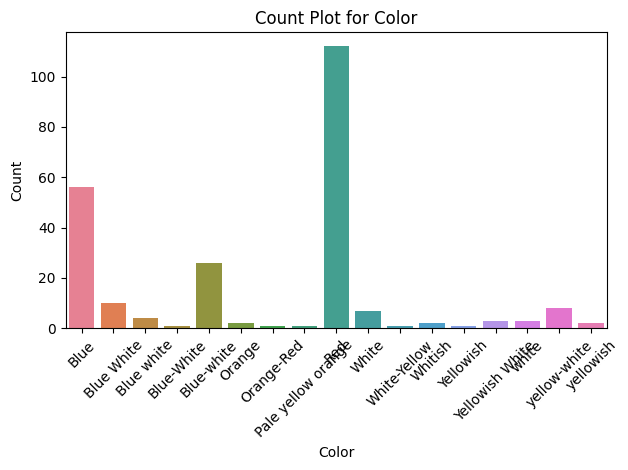

In [15]:
sns.countplot(data=data1, x='Color',hue='Color', legend=False,)#palette="viridis")
plt.title(f"Count Plot for Color")
plt.xlabel("Color")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

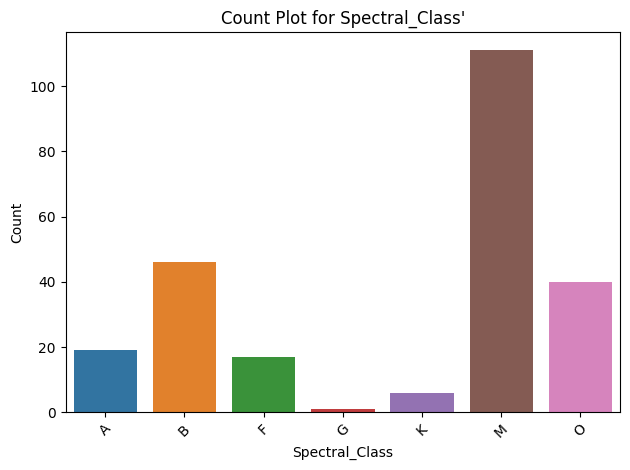

In [16]:
sns.countplot(data=data1, x='Spectral_Class',hue='Spectral_Class', legend=False,)#, palette="viridis")
plt.title(f"Count Plot for Spectral_Class'")
plt.xlabel('Spectral_Class')
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Target Label for Stars dataset

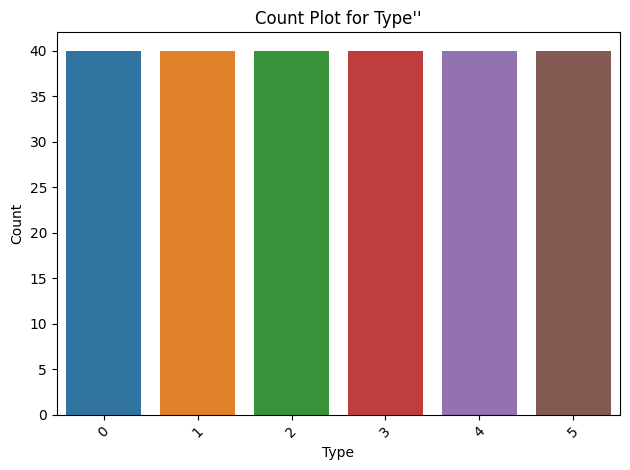

In [17]:
sns.countplot(data=data1, x='Type', hue='Type', legend=False,)#palette="viridis")
plt.title(f"Count Plot for Type''")
plt.xlabel('Type')
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

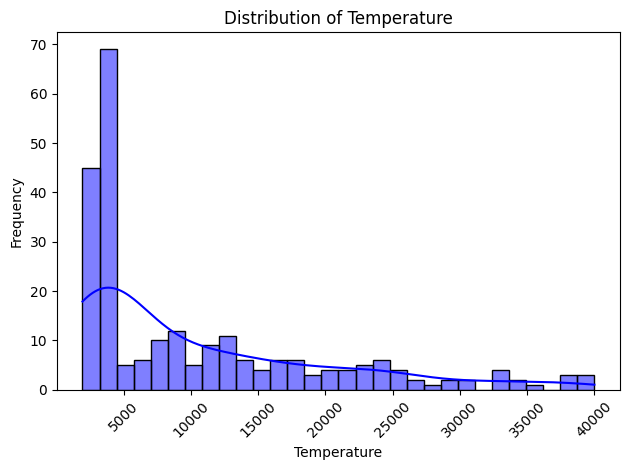

In [18]:
sns.histplot(data1['Temperature'], kde=True, bins=30, color='blue')
plt.title(f"Distribution of Temperature")
plt.xlabel('Temperature')
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

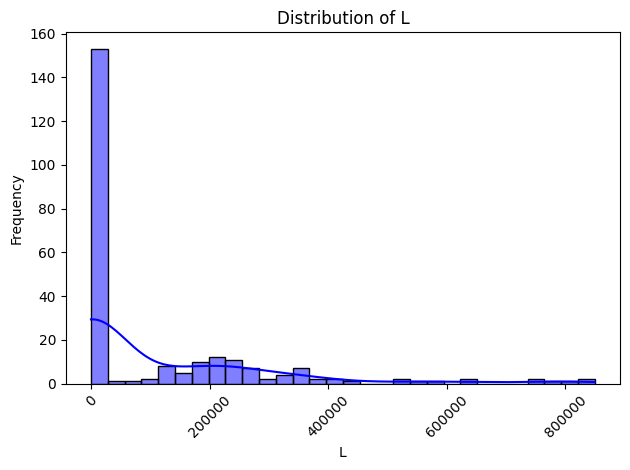

In [19]:
sns.histplot(data1['L'], kde=True, bins=30, color='blue')
plt.title(f"Distribution of L")
plt.xlabel('L')
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

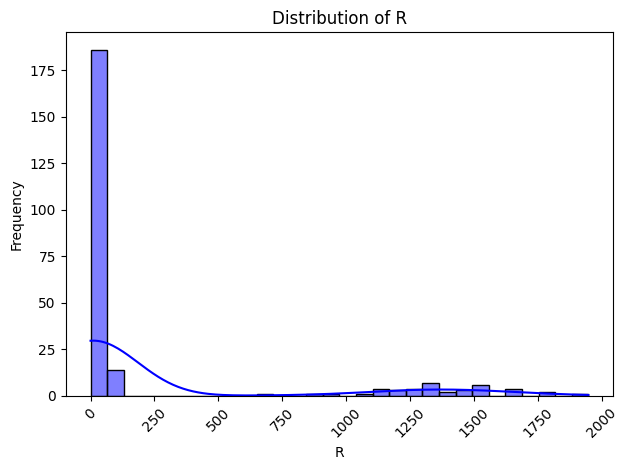

In [20]:
sns.histplot(data1['R'], kde=True, bins=30, color='blue')
plt.title(f"Distribution of R")
plt.xlabel('R')
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

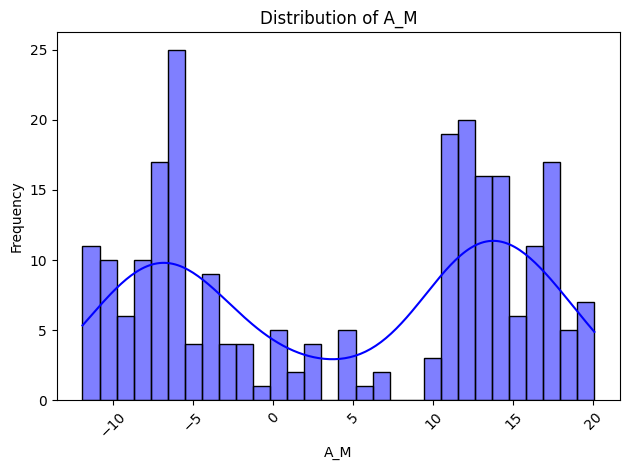

In [21]:
sns.histplot(data1['A_M'], kde=True, bins=30, color='blue')
plt.title(f"Distribution of A_M")
plt.xlabel('A_M')
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Splitting dataset in train and test data

In [22]:
X1, y1 = dataset.iloc[:, :-1], dataset.iloc[:, -1]
y1.head()

,Type
0,0
1,0
2,0
3,0
4,0


In [23]:
cat_features_list = X1.select_dtypes(include=['object']).columns
cat_features_list

Index(['Color', 'Spectral_Class'], dtype='object')

In [24]:

X1[cat_features_list] = X1[cat_features_list].apply(LabelEncoder().fit_transform)
X1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    int64  
 5   Spectral_Class  240 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 11.4 KB


In [25]:
X1, y1 = X1.values, LabelEncoder().fit_transform(y1)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, random_state=10)

## Case1: LDA

In [26]:
# Linear Discriminant Analysis
lda = LinearDiscriminantAnalysis()
lda.fit(X1_train, y1_train)

# Predictions
y_pred1 = lda.predict(X1_test)



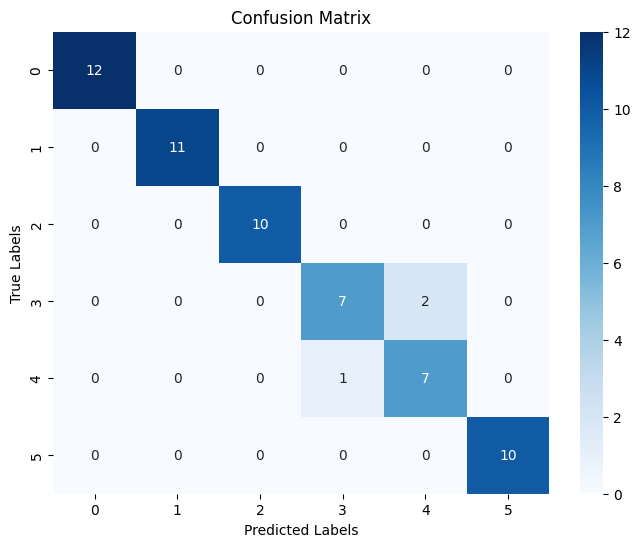

In [27]:
import seaborn as sns
# Evaluation
cm = confusion_matrix(y1_test, y_pred1)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=lda.classes_, yticklabels=lda.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [28]:
# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y1_test, y_pred1))
print("\nClassification Report:")
print(classification_report(y1_test, y_pred1))
print("\nAccuracy Score:")
print(accuracy_score(y1_test, y_pred1))

Confusion Matrix:
[[12  0  0  0  0  0]
 [ 0 11  0  0  0  0]
 [ 0  0 10  0  0  0]
 [ 0  0  0  7  2  0]
 [ 0  0  0  1  7  0]
 [ 0  0  0  0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        10
           3       0.88      0.78      0.82         9
           4       0.78      0.88      0.82         8
           5       1.00      1.00      1.00        10

    accuracy                           0.95        60
   macro avg       0.94      0.94      0.94        60
weighted avg       0.95      0.95      0.95        60


Accuracy Score:
0.95


## Cross Validation for LDA

In [29]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
scores = cross_val_score(LDA(), X1, y1, cv=4)
print("Accuracy: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std() * 2))

Accuracy: 0.9833 (+/- 0.0236)


In [30]:
X11 = standardize(X1)

lda1 = lda2(n_discriminants=None)
lda1.fit(X11, y1)
X_lda1 = lda1.transform(X11)

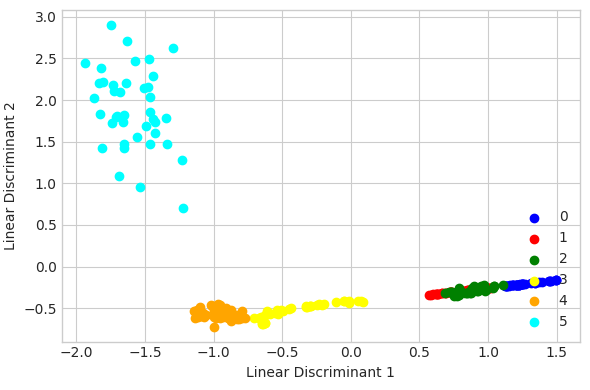

In [31]:
with plt.style.context('seaborn-v0_8-whitegrid'):
    plt.figure(figsize=(6, 4))
    for lab, col in zip((0, 1, 2,3,4,5),
                        ('blue', 'red', 'green','yellow','orange','cyan')):
        plt.scatter(X_lda1[y1 == lab, 0],
                    X_lda1[y1 == lab, 1],
                    label=lab,
                    c=col)
    plt.xlabel('Linear Discriminant 1')
    plt.ylabel('Linear Discriminant 2')
    plt.legend(loc='lower right')
    plt.tight_layout()

In [32]:
tot = sum(lda1.e_vals_)
var_exp = [(i / tot)*100 for i in sorted(lda1.e_vals_, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print (var_exp)

[81.0393685072078, 10.025948195082645, 7.766833604438912, 1.1378905186506167, 0.02995917462002607, -4.848776395586351e-16]


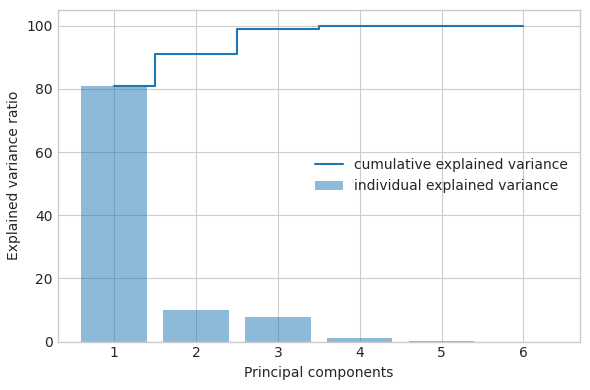

In [33]:
with plt.style.context('seaborn-v0_8-whitegrid'):
    fig, ax = plt.subplots(figsize=(6, 4))
    plt.bar(range(6), var_exp, alpha=0.5, align='center',
            label='individual explained variance')
    plt.step(range(6), cum_var_exp, where='mid',
             label='cumulative explained variance')
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal components')
    plt.xticks(range(6))
    ax.set_xticklabels(np.arange(1, X11.shape[1] + 1))
    plt.legend(loc='best')
    plt.tight_layout()

## Hyperparameter Tuning: looks like two componnents are sufficient

## Case2: SVM

In [34]:
# Standardize the numerical features
scaler = StandardScaler()
X2_train = scaler.fit_transform(X1_train)
X2_test = scaler.transform(X1_test)

In [35]:
X2 = scaler.fit_transform(X1)
print (X2.shape)
print (y1.shape)

(240, 6)
(240,)


In [36]:
# Create and train the SVM model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X2_train, y1_train)

# Make predictions
y_pred2 = svm_model.predict(X2_test)

In [37]:
# Evaluation
print("Confusion Matrix:")
cm2 = confusion_matrix(y1_test, y_pred2)
print(cm2)

print("\nClassification Report:")
print(classification_report(y1_test, y_pred2))

print("\nAccuracy Score:")
print(accuracy_score(y1_test, y_pred2))

Confusion Matrix:
[[12  0  0  0  0  0]
 [ 0 11  0  0  0  0]
 [ 0  0 10  0  0  0]
 [ 0  0  0  9  0  0]
 [ 0  0  0  1  7  0]
 [ 0  0  0  0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        10
           3       0.90      1.00      0.95         9
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


Accuracy Score:
0.9833333333333333


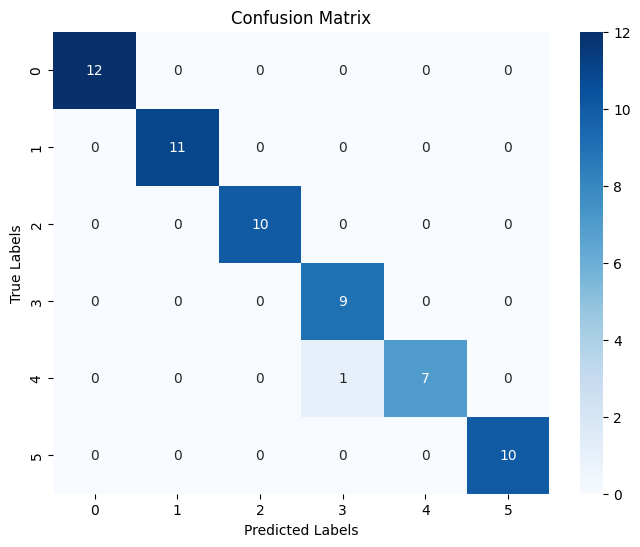

In [38]:
# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

## Cross Validation for SVM

In [39]:
svm_model2 = SVC(kernel='rbf', random_state=42)
scores2 = cross_val_score(svm_model2, X2, y1, cv=5)
print("Accuracy: %0.4f (+/- %0.4f)" % (scores2.mean(), scores2.std() * 2))
scores2

Accuracy: 0.9583 (+/- 0.0589)


array([1.        , 0.9375    , 0.95833333, 0.97916667, 0.91666667])

## Hyper Parameter tuning for SVM

In [63]:
from sklearn.model_selection import GridSearchCV


from sklearn.svm import SVC
param_grid = {
    'C': [0.1, 1,3, 5,10],
    'gamma': [0.001, 0.01, 0.1],
    'kernel': ['linear','poly', 'rbf']
}
grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X2, y1)
print(grid_search.best_params_)

{'C': 3, 'gamma': 0.001, 'kernel': 'linear'}


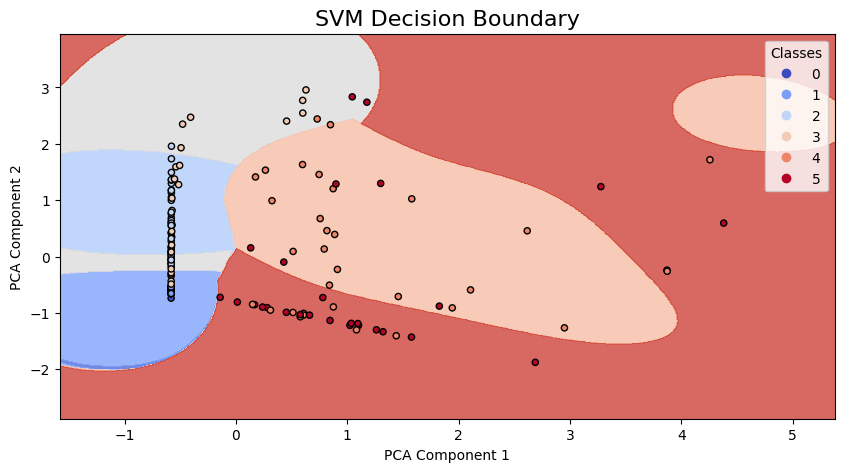

In [64]:
# Reduce features to 2 dimensions for visualization using PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X1)

# Train-test split
X_trainr, X_testr, y_trainr, y_testr = train_test_split(X_reduced, y1, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_trainr = scaler.fit_transform(X_trainr)
X_testr = scaler.transform(X_testr)

# Train the SVM model
svm_modelr = SVC(kernel='rbf', random_state=42)
svm_modelr.fit(X_trainr, y_trainr)

# Train the LDA model
lda_modelr = LinearDiscriminantAnalysis()
lda_modelr.fit(X_trainr, y_trainr)

# Function to plot decision boundaries
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 5))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.coolwarm, s=20)
    plt.title(title, fontsize=16)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.show()

# Plot SVM decision boundary
plot_decision_boundary(svm_modelr, X_trainr, y_trainr, "SVM Decision Boundary")



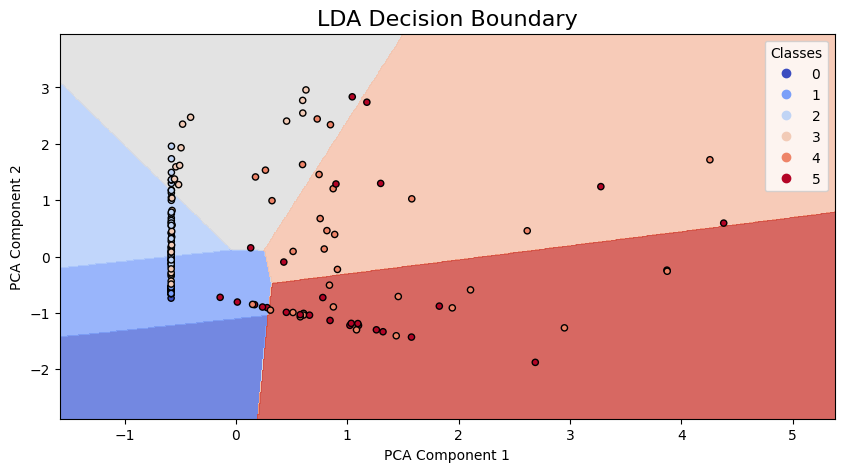

In [65]:
# Plot LDA decision boundary
plot_decision_boundary(lda_modelr, X_trainr, y_trainr, "LDA Decision Boundary")

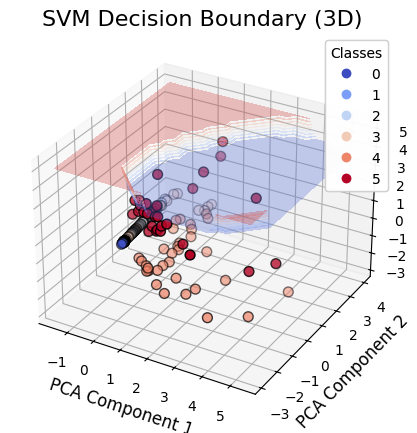

In [66]:
# Reduce features to 3 dimensions for visualization using PCA
pca = PCA(n_components=3)
X2_reduced = pca.fit_transform(X1)

# Train-test split
X_trainrr, X_testrr, y_trainrr, y_testrr = train_test_split(X2_reduced, y1, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_trainrr = scaler.fit_transform(X_trainrr)
X_testrr = scaler.transform(X_testrr)

# Train the SVM model
svm_modelrr = SVC(kernel='rbf', random_state=42)
svm_modelrr.fit(X_trainrr, y_trainrr)

# Train the LDA model
lda_modelrr = LinearDiscriminantAnalysis()
lda_modelrr.fit(X_trainrr, y_trainrr)

# Function to plot 3D decision boundaries
def plot_3d_decision_boundary(model, X, y, title):
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111, projection='3d')

    # Create a grid of points
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    z_min, z_max = X[:, 2].min() - 1, X[:, 2].max() + 1
    xx, yy, zz = np.meshgrid(
        np.linspace(x_min, x_max, 30),
        np.linspace(y_min, y_max, 30),
        np.linspace(z_min, z_max, 30)
    )

    # Predict on the grid
    grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    # Plot decision boundary (isosurface)
    ax.contourf(xx[:, :, 0], yy[:, :, 0], Z[:, :, 0], alpha=0.3, cmap=plt.cm.coolwarm)

    # Plot data points
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap=plt.cm.coolwarm, edgecolor='k', s=50)

    # Plot settings
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("PCA Component 1", fontsize=12)
    ax.set_ylabel("PCA Component 2", fontsize=12)
    ax.set_zlabel("PCA Component 3", fontsize=12)
    legend = ax.legend(*scatter.legend_elements(), title="Classes", loc="best")
    ax.add_artist(legend)
    plt.show()

# Plot SVM decision boundary
plot_3d_decision_boundary(svm_modelrr, X_trainrr, y_trainrr, "SVM Decision Boundary (3D)")


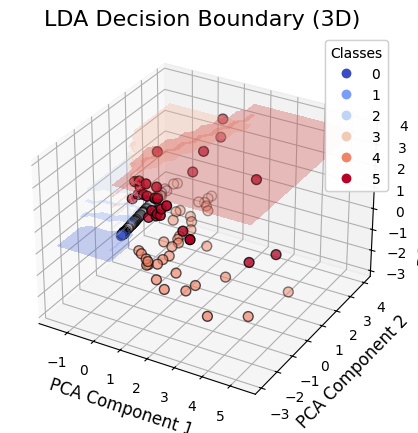

In [67]:

# Plot LDA decision boundary
plot_3d_decision_boundary(lda_modelrr, X_trainrr, y_trainrr, "LDA Decision Boundary (3D)")

# By Rishi Ram

## Case3: Neural Networks

In [44]:
#importing all libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import yfinance as yf

In [45]:
# Download Tesla stock data
tesla = yf.Ticker("TSLA")
df = tesla.history(period="5y")

# Create additional features
df['Returns'] = df['Close'].pct_change()
df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA21'] = df['Close'].rolling(window=21).mean()
df['Volume_MA7'] = df['Volume'].rolling(window=7).mean()

In [46]:
# Drop NaN values
df = df.dropna()

# Prepare features
features = ['Close', 'Returns', 'MA7', 'MA21', 'Volume', 'Volume_MA7']
target = 'Close'

# Scale the features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Scale features and target separately
X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])

In [47]:
print (len(X_scaled))

1238


In [48]:
# Create sequences with multiple features
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:(i + seq_length)])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

In [49]:
# Parameters
sequence_length = 30  # Reduced from 60 to capture more recent patterns
X, y = create_sequences(X_scaled, y_scaled, sequence_length)

# Split the data with a smaller test size
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)


In [50]:
X.shape

(1208, 30, 6)

In [51]:
# Build an improved model
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(sequence_length, len(features))),
    Dropout(0.3),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [52]:
# Compile with a lower learning rate
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='huber')  # Huber loss is more robust to outliers

# Add early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [53]:

# Train the model with a larger batch size
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - loss: 0.0688 - val_loss: 0.0085
Epoch 2/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0099 - val_loss: 0.0034
Epoch 3/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0058 - val_loss: 0.0031
Epoch 4/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - loss: 0.0047 - val_loss: 0.0028
Epoch 5/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0041 - val_loss: 0.0026
Epoch 6/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0042 - val_loss: 0.0025
Epoch 7/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0039 - val_loss: 0.0022
Epoch 8/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0032 - val_loss: 0.0022
Epoch 9/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0033 - val_loss: 0.0020
Epoch 10/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 11/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0029 - val_loss: 0.0018
Epoch 12/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss:

In [54]:
# Make predictions
predictions = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step


In [55]:
# Inverse transform predictions and actual values
predictions = scaler_y.inverse_transform(predictions)
y_test_inv = scaler_y.inverse_transform(y_test)

# Inverse transform predictions and actual values
#predictions = scaler_y.inverse_transform(predictions)
#y_test_inv = scaler_y.inverse_transform(y_test)

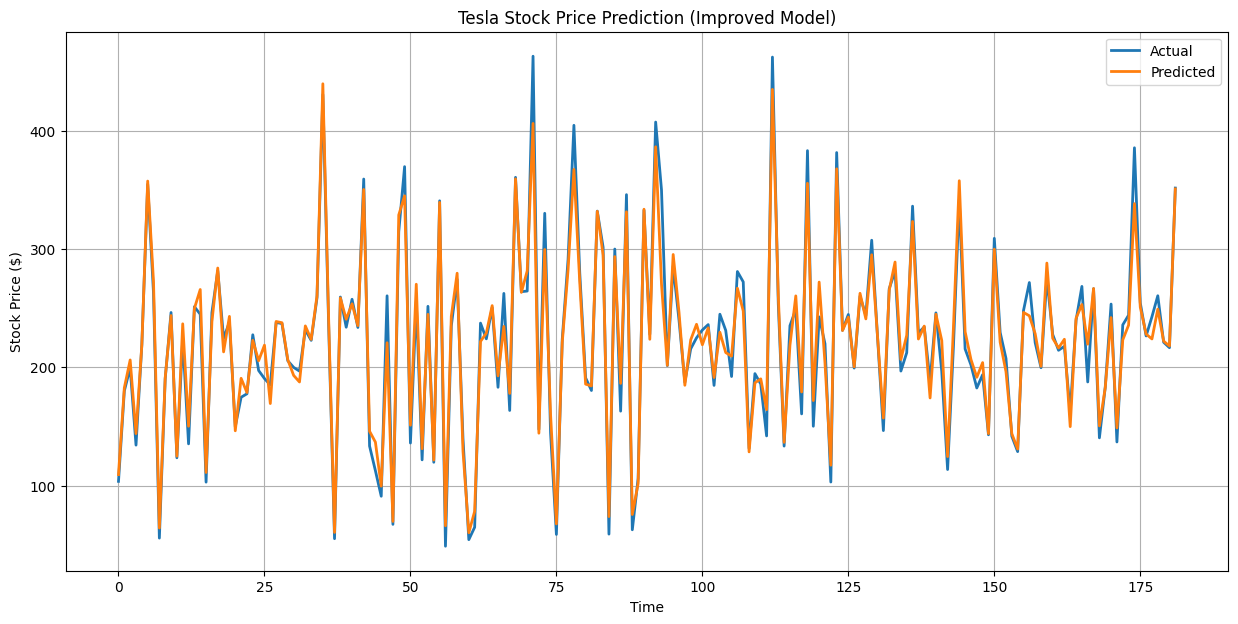

In [56]:
# Plot results
plt.figure(figsize=(15, 7))
plt.plot(y_test_inv, label='Actual', linewidth=2)
plt.plot(predictions, label='Predicted', linewidth=2)
plt.title('Tesla Stock Price Prediction (Improved Model)')
plt.xlabel('Time')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True)
plt.show()

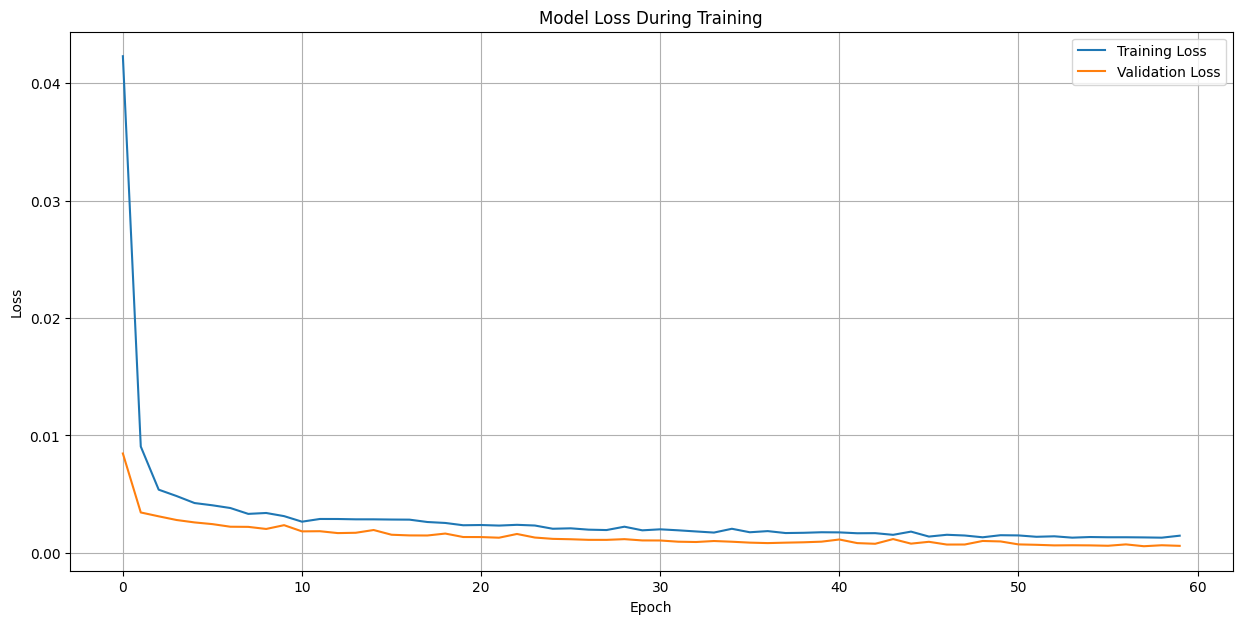

In [57]:
# Plot training history
plt.figure(figsize=(15, 7))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()